# MED-01 · Hospital Appointment No-Show Prediction: the full project in one notebook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/monfurkat-glitch/HealthProject/blob/main/notebooks/00_full_project.ipynb)

**Student:** Furkat Toshmatov · **Track 1:** Individual Project · **Domain:** MedTech · **Repository:** https://github.com/monfurkat-glitch/HealthProject

This notebook runs the **entire project from the raw CSV to the final predictions**, step by step:

| # | Step | Code |
|---|---|---|
| 1 | Setup | clones the repository |
| 2 | Problem and ML task | |
| 3 | Data and exploratory analysis | `notebooks/01_eda.ipynb` has the full EDA |
| 4 | Preprocessing, time split, leakage tests | `src/preprocess.py` |
| 5 | Baselines and 23 experiments, bootstrap comparison | `src/train.py`, `src/evaluate.py` |
| 6 | Pre-registered final model and one-time test evaluation | `src/final.py` |
| 7 | Error analysis and fairness | `src/error_analysis.py` |
| 8 | Predicting new appointments | `src/predict.py` |
| 9 | Reproducibility checks | |
| 10 | Responsible AI, limitations, all tests | `docs/responsible_ai.md` |

**How to run:** in Google Colab choose **Runtime → Run all**. Everything is re-computed live; it takes about **5–10 minutes** on a Colab CPU (most of it in step 5). Set `FAST = True` below to skip re-training the 13 tree-model experiments and read their logged results instead (about 2 minutes).

## 1. Setup

In [1]:
FAST = False   # True: skip re-running the random-forest and gradient-boosting grids (uses their logged results)

import os, subprocess, sys
from pathlib import Path

REPO_URL = "https://github.com/monfurkat-glitch/HealthProject.git"
if "google.colab" in sys.modules and not Path("HealthProject").exists():
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
for candidate in [Path("HealthProject"), Path(".."), Path(".")]:
    if (candidate / "src" / "preprocess.py").exists():
        os.chdir(candidate)
        break
sys.path.insert(0, os.getcwd())

import importlib.metadata as md
if md.version("scikit-learn") != "1.7.2":      # the saved model was built with this version
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scikit-learn==1.7.2"], check=True)
try:
    import pytest  # noqa: F401
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pytest==8.4.2"], check=True)

import json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160); pd.set_option("display.max_colwidth", 90)
print("Working directory:", os.getcwd(), "| scikit-learn", md.version("scikit-learn"))

def show(name, width=900):
    """Display a saved figure from reports/figures/."""
    display(Image(filename=f"reports/figures/{name}.png", width=width))

Working directory: C:\Users\Admin\AppData\Local\Temp\claude\D--AIML-Project-Health\ef3e4846-9b95-4b63-ad6b-7510a271ffea\scratchpad\fresh2 | scikit-learn 1.7.2


## 2. Problem and ML task

**Problem.** A private healthcare network loses clinic capacity to unannounced no-shows: **1 in 5** appointments in the data is missed. Staff cannot tell who is likely to miss, so reminders are spread evenly.

**Goal.** For every booked appointment, estimate the no-show risk **at booking time** so staff can prioritise reminders and confirmation calls. The system only **informs** staff; it never cancels, rebooks, or refuses care.

| | |
|---|---|
| **Task** | Supervised binary classification (tabular data) |
| **Input** | One appointment: age, gender, neighbourhood, welfare status, health flags, booking and appointment dates, the patient's past attendance known at booking time |
| **Target** | `No-show` (Yes = did not attend) |
| **Output** | No-show probability, Low / Medium / High risk band, main factors |
| **Metrics** | ROC-AUC, PR-AUC, precision and recall among the riskiest 20% (staff capacity), Brier score; **not accuracy** (always guessing "attends" is ~81% accurate) |

## 3. Data and exploratory analysis

*Medical Appointment No Shows* (Kaggle; Joni Hoppen and Aquarela Analytics; CC BY-NC-SA 4.0): public clinics in Vitória, Brazil. The CSV is in the repository (`Data/`).

In [2]:
from src.preprocess import load_raw
raw = load_raw()
print(f"{len(raw):,} appointments · {raw['PatientId'].nunique():,} patients · {raw.shape[1]} columns · "
      f"{raw.isna().sum().sum()} missing values · {raw.duplicated().sum()} duplicate rows")
print(f"No-show rate: {(raw['No-show'] == 'Yes').mean():.1%}")
raw.head()

110,527 appointments · 62,299 patients · 14 columns · 0 missing values · 0 duplicate rows
No-show rate: 20.2%


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,29872499824296,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,558997776694438,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4262962299951,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,867951213174,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8841186448183,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
appt = pd.to_datetime(raw["AppointmentDay"]).dt.tz_localize(None)
sched = pd.to_datetime(raw["ScheduledDay"]).dt.tz_localize(None).dt.normalize()
lead = (appt - sched).dt.days
issues = pd.Series({
    "Age < 0 (invalid)": (raw["Age"] < 0).sum(),
    "Booked after the appointment (invalid)": (lead < 0).sum(),
    "Handcap > 1 (a 0-4 count, not yes/no)": (raw["Handcap"] > 1).sum(),
    "Neighbourhoods with < 50 appointments": (raw["Neighbourhood"].value_counts() < 50).sum(),
    "Distinct appointment dates": appt.nunique(),
}, name="count")
print(f"Appointment dates: {appt.min().date()} to {appt.max().date()}")
issues.to_frame()

Appointment dates: 2016-04-29 to 2016-06-08

,count
Age < 0 (invalid),1
Booked after the appointment (invalid),5
"Handcap > 1 (a 0-4 count, not yes/no)",199
Neighbourhoods with < 50 appointments,5
Distinct appointment dates,27


**Lead time is the strongest signal**, and **SMS reminders are confounded with it** (they were only sent for bookings made 3+ days ahead):

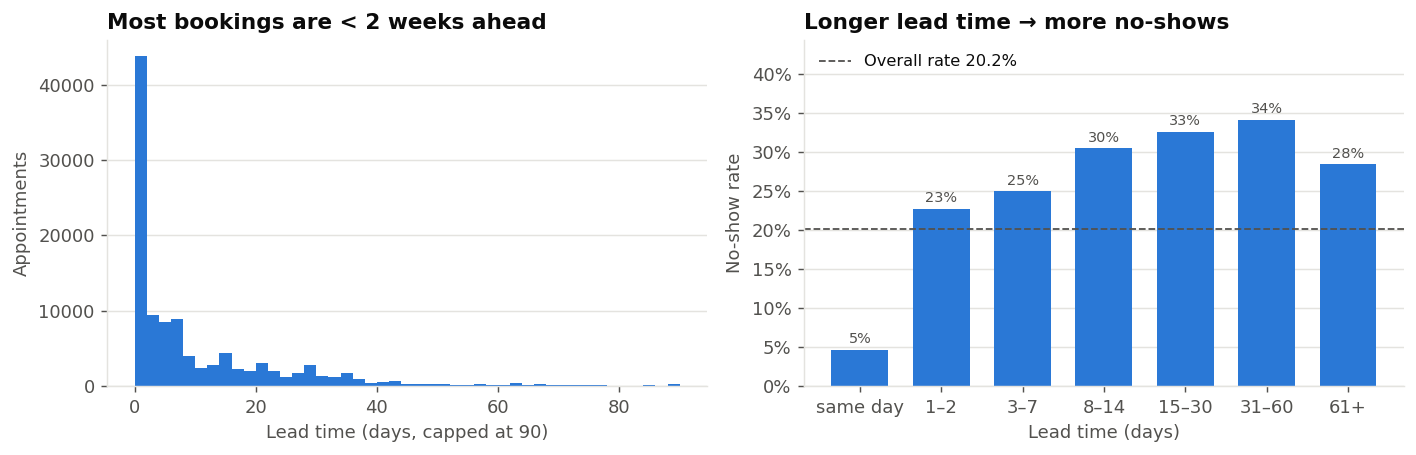

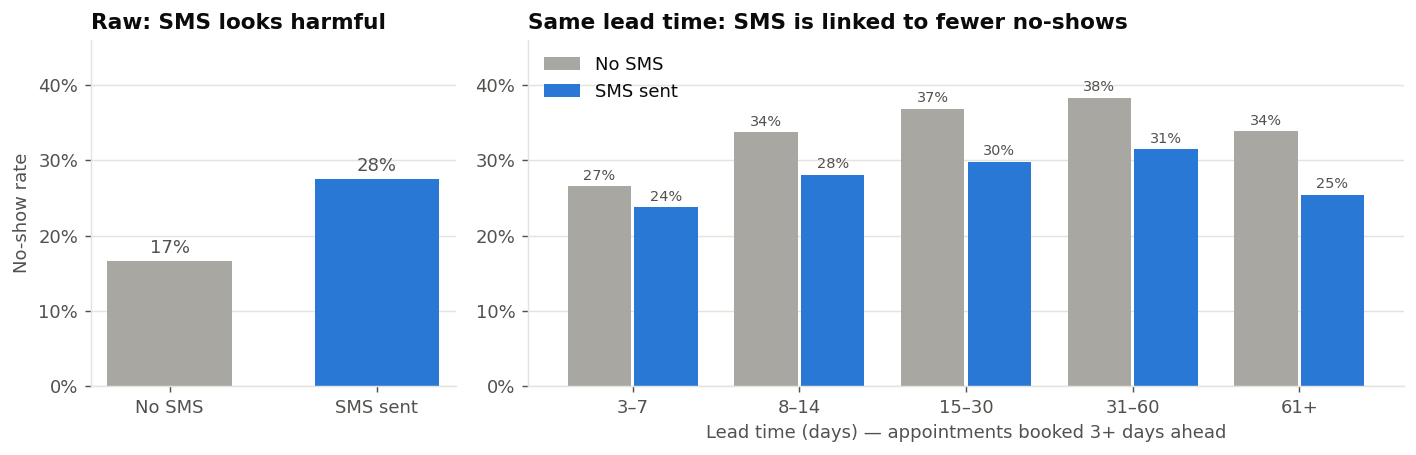

In [4]:
show("02_lead_time"); show("03_sms_confounding")

**Age** has a non-linear effect; health flags, gender, and weekday matter little:

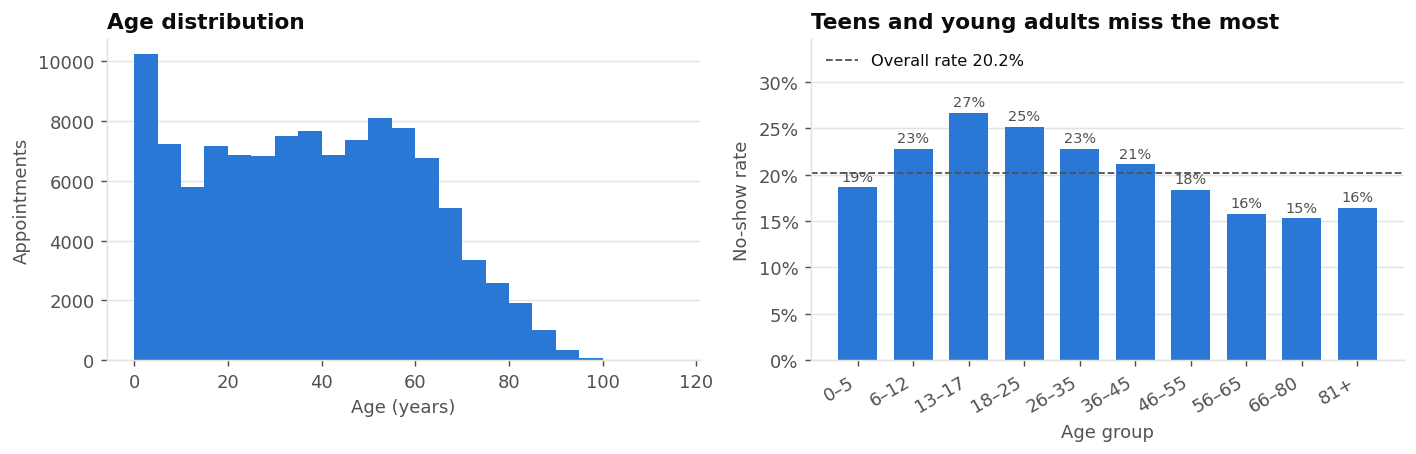

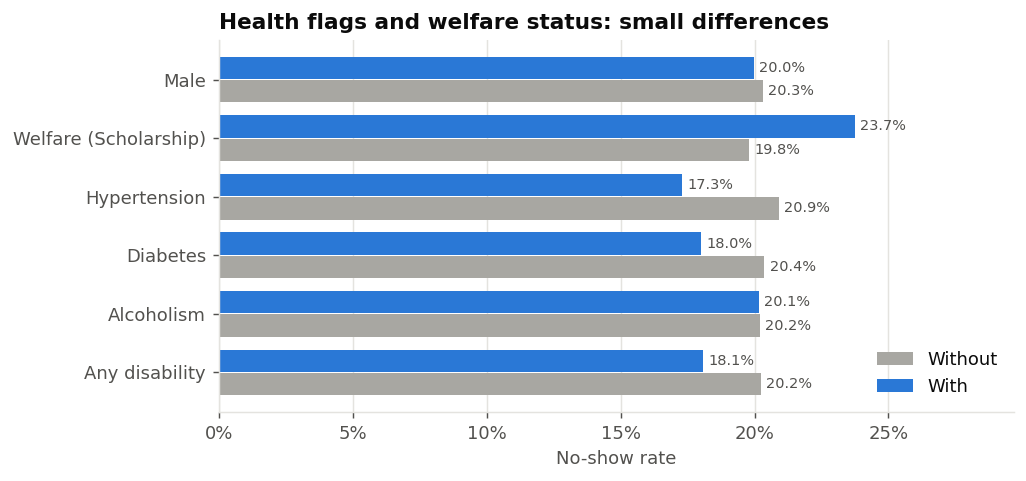

In [5]:
show("04_age"); show("05_patient_flags", 700)

**Patient history can leak the future**: only appointments dated before the booking day may be counted. The leaky version (right) looks more predictive than it could ever be in real use:

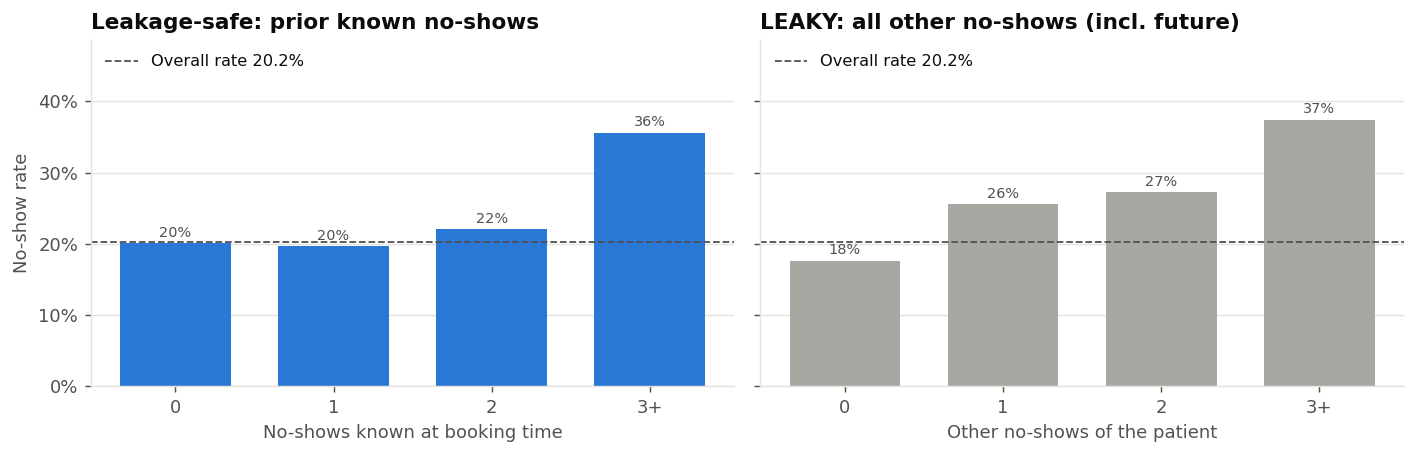

In [6]:
show("09_patient_history")

## 4. Preprocessing, time split, and leakage tests

`src/preprocess.py` is shared by training and prediction:

- **clean**: rename columns, parse dates, encode the target, drop impossible rows;
- **add_history_features**: `prior_appointments`, `prior_no_shows`, `prior_no_show_rate`, counting only appointments dated **strictly before the booking day**;
- **add_features**: `lead_days`, `same_day`, `appointment_weekday`, `male`, `disability`;
- **build_preprocessor**: scaling plus one-hot encoding, rare and unseen neighbourhoods grouped, **fitted on training data only**;
- **time_split**: chronological train / validation / test.

`SMS_received` is excluded: reminders are sent after booking, so SMS status is unknown at prediction time.

In [7]:
from src.preprocess import build_dataset, time_split, split_summary, feature_columns, TARGET
t0 = time.time()
data = build_dataset(raw)
train, val, test = time_split(data)
print(f"After cleaning: {len(data):,} rows ({len(raw) - len(data)} impossible rows dropped) · built in {time.time() - t0:.0f}s")
print("Model features:", feature_columns())
summary = split_summary(train, val, test)
summary["share"] = summary["share"].map("{:.1%}".format); summary["no-show rate"] = summary["no-show rate"].map("{:.1%}".format)
summary

After cleaning: 110,521 rows (6 impossible rows dropped) · built in 1s
Model features: ['age', 'lead_days', 'prior_appointments', 'prior_no_shows', 'prior_no_show_rate', 'male', 'scholarship', 'hypertension', 'diabetes', 'alcoholism', 'disability', 'same_day', 'neighbourhood', 'appointment_weekday']


,rows,share,first day,last day,no-show rate
train,75278,68.1%,2016-04-29,2016-05-25,21.0%
validation,17567,15.9%,2016-05-30,2016-06-02,18.6%
test,17676,16.0%,2016-06-03,2016-06-08,18.5%


In [8]:
data[["patient_id", "scheduled_day", "appointment_day", "lead_days", "prior_appointments", "prior_no_shows", "age",
      "neighbourhood", TARGET]].sample(5, random_state=3)

,patient_id,scheduled_day,appointment_day,lead_days,prior_appointments,prior_no_shows,age,neighbourhood,no_show
81876,47675192562373,2016-05-02 08:00:50,2016-05-02,0,0,0,3,ITARARÉ,0
31998,31686557632277,2016-05-17 11:22:27,2016-05-17,0,0,0,4,JABOUR,0
80692,772896368633828,2016-05-16 17:05:19,2016-05-18,2,2,0,41,JARDIM DA PENHA,0
106600,71842123437414,2016-05-25 15:21:57,2016-06-08,14,2,0,45,ILHA DAS CAIEIRAS,1
40416,47955574182619,2016-05-11 12:05:13,2016-05-11,0,0,0,14,JOANA D´ARC,0


The leakage tests compare the history features with a brute-force recount on real data and check that changing *future* outcomes never changes a feature:

In [9]:
r = subprocess.run([sys.executable, "-m", "pytest", "-q", "--color=no", "tests/test_preprocess.py"], capture_output=True, text=True)
print(r.stdout.strip().splitlines()[-1])

10 passed in 7.50s


## 5. Baselines and experiments

Every model is trained on the **train** period and scored on the **validation** period. The test period is not touched here. Each run is appended to `experiments/runs.csv` with the git commit.

In [10]:
from src.train import run
t0 = time.time()
baselines = run("baselines")
lr_tuning = run("logreg_tuning")
print(f"done in {time.time() - t0:.0f}s")
pd.concat({"baselines": baselines, "logistic regression tuning": lr_tuning}).drop(columns="no_show_rate").round(3)

done in 10s


roc_auc  pr_auc  precision_top20  recall_top20  brier  train_roc_auc
                           run                                                                                  
baselines                  majority_class     0.500   0.186            0.192         0.206  0.152          0.500
                           lead_time_rule     0.693   0.284            0.305         0.328  0.141          0.703
                           logreg             0.726   0.332            0.340         0.365  0.138          0.728
                           logreg_balanced    0.725   0.332            0.340         0.365  0.221          0.728
                           logreg_with_sms    0.727   0.334            0.341         0.366  0.138          0.729
logistic regression tuning logreg_C0.001      0.722   0.322            0.334         0.359  0.139          0.723
                           logreg_C0.01       0.726   0.332            0.337         0.362  0.138          0.727
                           logreg_C0.1        0.726   0.332            0.340         0.365  0.138          0.728
                           logreg_C1.0        0.726   0.332            0.340         0.365  0.138          0.728
                           logreg_C10.0       0.726   0.332            0.340         0.365  0.138          0.728

In [11]:
from src.experiments import load_runs
if FAST:
    logged = load_runs()
    logged = logged[logged["experiment"].isin(["random_forest", "gradient_boosting"])].drop_duplicates("run_name")
    trees = logged.set_index(["experiment", "run_name"])[["roc_auc", "pr_auc", "precision_top20", "recall_top20", "brier", "train_roc_auc"]]
    print("FAST mode: logged results (not re-trained)")
else:
    t0 = time.time()
    trees = pd.concat({"random forest": run("random_forest"), "gradient boosting": run("gradient_boosting")}).drop(columns="no_show_rate")
    print(f"13 tree models trained in {time.time() - t0:.0f}s")
trees.astype(float).round(3)

13 tree models trained in 127s


roc_auc  pr_auc  precision_top20  recall_top20  brier  train_roc_auc
                  run                                                                                              
random forest     rf_leaf1_featsqrt              0.700   0.297            0.313         0.337  0.153          0.999
                  rf_leaf20_featsqrt             0.726   0.323            0.338         0.363  0.138          0.773
                  rf_leaf100_featsqrt            0.723   0.312            0.331         0.356  0.138          0.742
                  rf_leaf20_feat0.5              0.722   0.320            0.332         0.357  0.139          0.817
gradient boosting hgb_default                    0.728   0.330            0.338         0.364  0.138          0.777
                  hgb_lr0.03_leaves15_leaf20     0.728   0.335            0.339         0.365  0.138          0.755
                  hgb_lr0.03_leaves15_leaf200    0.729   0.331            0.342         0.368  0.138          0.759
                  hgb_lr0.03_leaves63_leaf20     0.725   0.328            0.332         0.357  0.139          0.800
                  hgb_lr0.03_leaves63_leaf200    0.726   0.326            0.342         0.368  0.139          0.777
                  hgb_lr0.1_leaves15_leaf20      0.728   0.334            0.335         0.360  0.138          0.758
                  hgb_lr0.1_leaves15_leaf200     0.728   0.331            0.345         0.371  0.138          0.763
                  hgb_lr0.1_leaves63_leaf20      0.726   0.330            0.338         0.363  0.139          0.787
                  hgb_lr0.1_leaves63_leaf200     0.725   0.326            0.341         0.366  0.139          0.772

**Reading the tables:**
- The **lead-time rule** (no ML) already reaches about 0.69; logistic regression about 0.73.
- **Class weights** leave the ranking unchanged but make the probabilities worse (higher Brier).
- **Fully grown random-forest trees overfit** (train ROC-AUC 0.999, validation 0.700); limiting leaf size fixes it.
- All reasonable models land around **0.73**.

**Is the best model really better?** A paired bootstrap resamples the validation rows 1,000 times and compares each model with logistic regression on the same rows:

In [12]:
from src.train import compare
t0 = time.time()
comparison = compare()
print(f"done in {time.time() - t0:.0f}s")
comparison.round(4)

done in 40s


,model,metric,mean_diff,ci_low,ci_high,share_better
0,random_forest,roc_auc,0.0005,-0.0042,0.0053,0.596
1,random_forest,recall_top20,-0.0033,-0.0181,0.0097,0.323
2,gradient_boosting,roc_auc,0.0031,-0.0021,0.0083,0.870
3,gradient_boosting,recall_top20,0.0021,-0.0119,0.0152,0.618


Every 95% interval (`ci_low` to `ci_high`) contains zero: **no model is reliably better than logistic regression on validation.**

## 6. Final model and one-time test evaluation

The final model was chosen **on validation evidence only**, and the decision was committed to git **before** the test set was used (`docs/final_model.md`). Logistic regression: equal performance within noise, simpler, no overfitting, explainable.

In [13]:
text = Path("docs/final_model.md").read_text(encoding="utf-8")
display(Markdown(text.split("## Comparison model")[0]))

# Final model decision (pre-registered)

This decision was made **using validation results only** and committed to git **before** any model was scored on the test set. The commit date is the proof. The test result is reported whatever it turns out to be, and the choice below does not change based on it.

## Final model

**Logistic regression** (`C = 1.0`, no class weights), using the default feature set from `src/preprocess.py` (14 features, SMS status excluded).

### Why (validation evidence, see [experiments/README.md](../experiments/README.md))

1. **Equal performance:** ROC-AUC 0.726, the same as the best random forest (0.726) and within noise of the best gradient boosting (0.729). A paired bootstrap found no model reliably better than logistic regression (every 95% interval for the difference includes zero).
2. **Simpler and explainable:** each feature has one coefficient, so staff and reviewers can see why an appointment is flagged.
3. **No overfitting:** train and validation ROC-AUC are almost equal (0.728 vs 0.726).
4. **Good probabilities:** Brier score 0.138, as good as any other model tried.



`src/final.py` refits the final model, the comparison model, and the baselines on train + validation, fixes the risk-band cut-offs, and scores the **test week** (2016-06-03 to 06-08). Running it here reproduces the committed evaluation. It does not choose anything.

In [14]:
from src import final
t0 = time.time()
results = final.main()
print(f"done in {time.time() - t0:.0f}s · test set: {results['test_rows']:,} appointments, {results['test_no_show_rate']:.1%} no-shows\n")
display(pd.DataFrame(results["metrics"]).T.drop(columns="no_show_rate"))   # already rounded to 4 decimals
print("Final model, 95% bootstrap intervals:")
display(pd.DataFrame(results["final_logreg_95ci"]).T)
print("Gradient boosting minus logistic regression on test (paired bootstrap):")
display(pd.DataFrame(results["hgb_minus_logreg"]))

done in 36s · test set: 17,676 appointments, 18.5% no-shows



,roc_auc,pr_auc,precision_top20,recall_top20,brier
final_logreg,0.7232,0.3283,0.3349,0.3623,0.1376
comparison_hgb,0.7365,0.3424,0.3562,0.3853,0.1356
baseline_majority,0.5000,0.1849,0.1678,0.1815,0.1511
baseline_lead_time_rule,0.6916,0.2781,0.2823,0.3054,0.1398


Final model, 95% bootstrap intervals:


,estimate,ci_low,ci_high
roc_auc,0.7232,0.7149,0.7319
pr_auc,0.3283,0.3152,0.3428
precision_top20,0.3349,0.3199,0.3513
recall_top20,0.3623,0.3491,0.3790
brier,0.1376,0.1349,0.1404


Gradient boosting minus logistic regression on test (paired bootstrap):


,model,metric,mean_diff,ci_low,ci_high,share_better
0,comparison_hgb,roc_auc,0.0134,0.0088,0.0179,1.0
1,comparison_hgb,recall_top20,0.0229,0.0098,0.0357,1.0


Risk-band cut-offs: [0.2333, 0.3233]


,appointments,no_shows,share_of_appointments,no_show_rate,share_of_all_no_shows
band,,,,,
Low,8776,710,0.4965,0.0809,0.2173
Medium,4910,1234,0.2778,0.2513,0.3776
High,3990,1324,0.2257,0.3318,0.4051


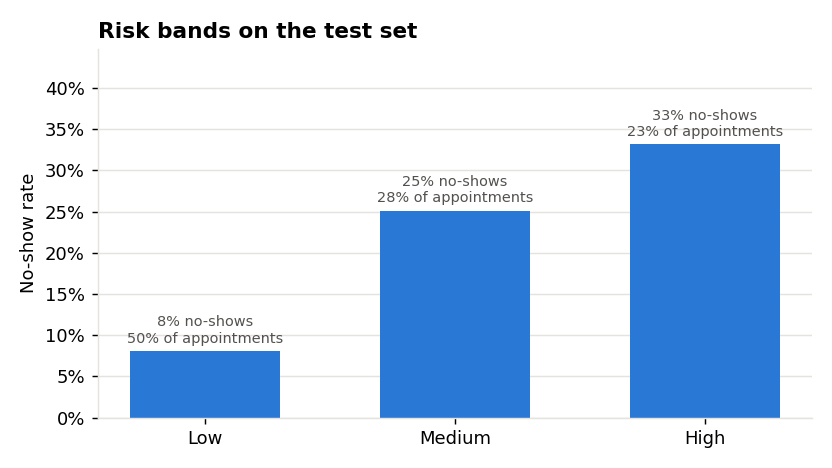

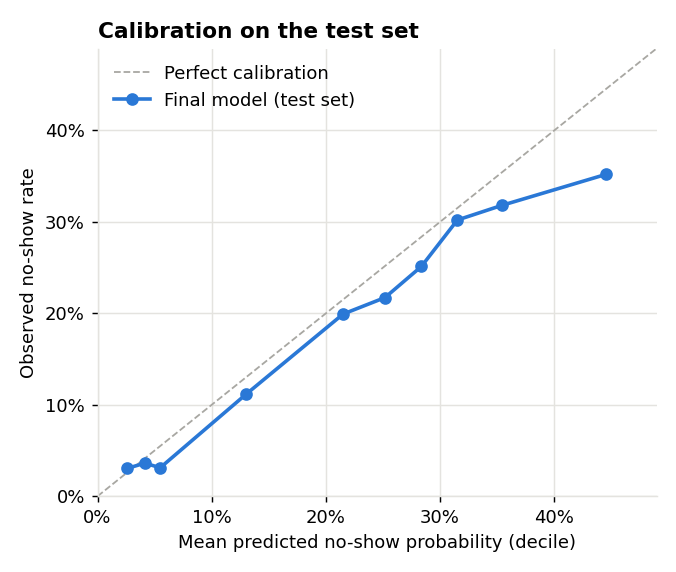

In [15]:
print("Risk-band cut-offs:", results["band_cutoffs"])
display(pd.DataFrame(results["bands"]).set_index("band"))
show("11_risk_bands", 650); show("11_calibration", 450)

**Results:**
- Test ROC-AUC **0.723** matches validation (0.726), so the model generalises and clearly beats both baselines.
- The **High** band (~23% of appointments) contains **~41% of all no-shows**; a High appointment is about 4× as likely to be missed as a Low one.
- **Honest finding:** gradient boosting was reliably better on the test week (+0.013). The pre-registered choice is kept so the test score stays unbiased; gradient boosting is recommended for a future version.
- Probabilities are slightly too high on the test week (base rate fell), so they are read as relative risk.

## 7. Error analysis and fairness

High-band outcomes: {'caught_no_shows_TP': 1324, 'false_alarms_FP': 2666, 'missed_no_shows_FN': 1944, 'correct_not_flagged_TN': 11742}


,appointments,mean_age,median_lead_days,same_day_share,welfare_share,has_history_share,mean_probability
outcome,,,,,,,
caught no-show (TP),1324,22.604,20.0,0.017,0.195,0.394,0.401
correctly not flagged (TN),11742,41.519,1.0,0.498,0.077,0.494,0.147
false alarm (FP),2666,22.526,18.0,0.006,0.177,0.380,0.387
missed no-show (FN),1944,42.129,7.0,0.118,0.049,0.459,0.235


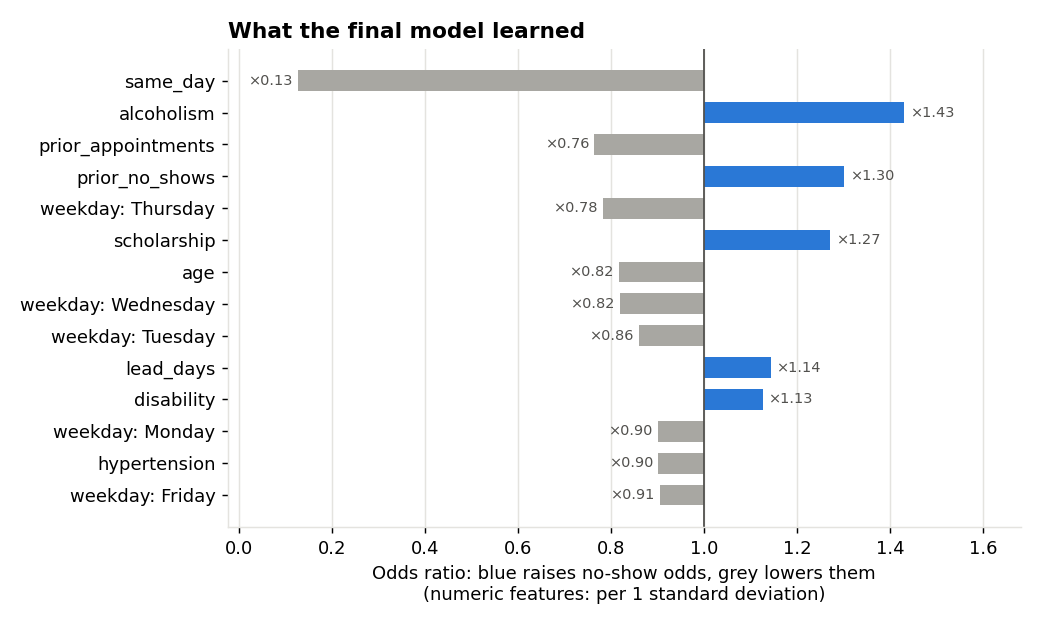

In [16]:
from src import error_analysis
ea = error_analysis.main()
print("High-band outcomes:", ea["confusion_high_band"])
display(pd.DataFrame(ea["error_profile"]).set_index("outcome").round(3))
show("12_coefficients", 750)

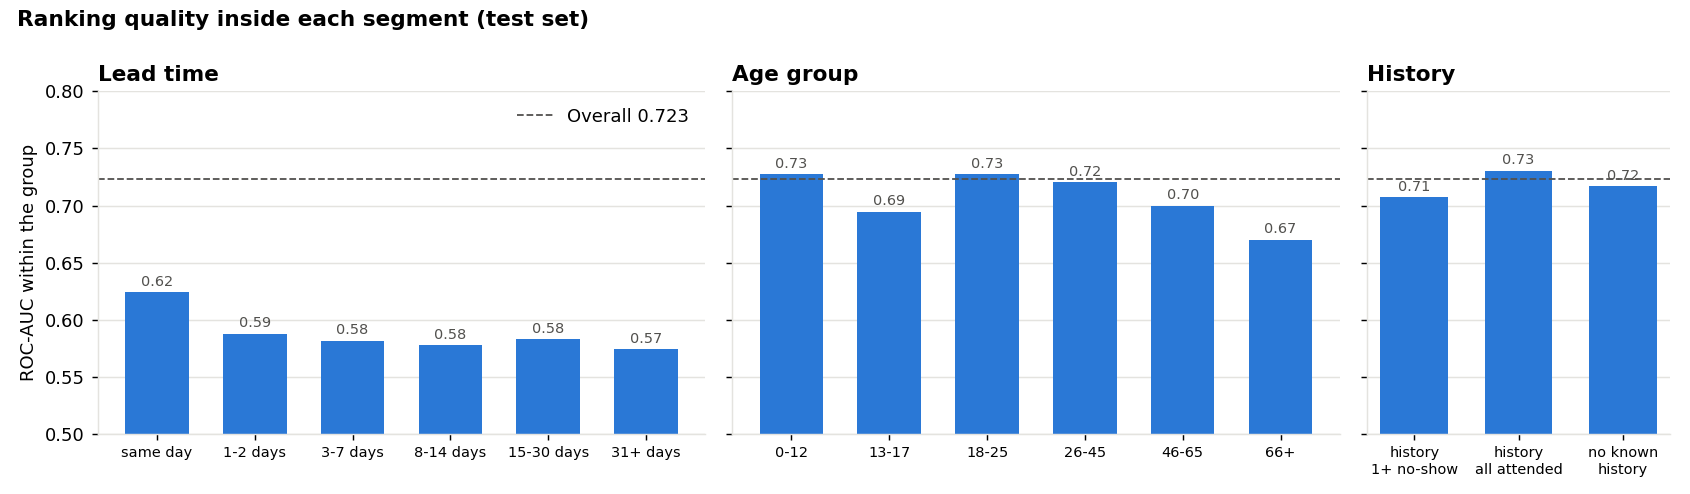

,appointments,no_show_rate,mean_predicted,flag_rate,recall_in_high,false_alarm_rate
gender,,,,,,
female,11664,0.183,0.212,0.213,0.396,0.172
male,6012,0.188,0.212,0.250,0.423,0.210


,appointments,no_show_rate,mean_predicted,flag_rate,recall_in_high,false_alarm_rate
welfare,,,,,,
no welfare,15946,0.183,0.207,0.204,0.366,0.168
welfare (Scholarship),1730,0.205,0.252,0.422,0.729,0.343


,appointments,no_show_rate,mean_predicted,flag_rate,recall_in_high,false_alarm_rate
age_group,,,,,,
0-12,3465,0.184,0.245,0.432,0.702,0.370
13-17,979,0.255,0.242,0.399,0.608,0.328
18-25,1729,0.242,0.238,0.344,0.554,0.276
26-45,4457,0.204,0.214,0.219,0.359,0.184
46-65,4845,0.153,0.190,0.089,0.194,0.070
66+,2201,0.141,0.168,0.045,0.071,0.041


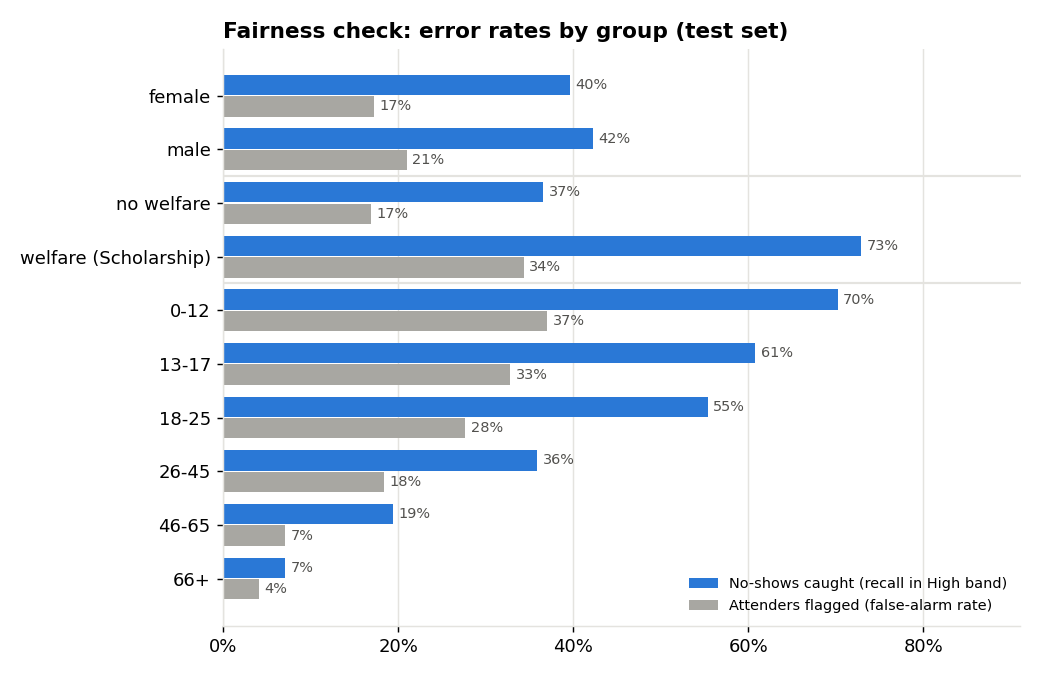

In [17]:
show("13_segments", 1000)
for group in ["gender", "welfare", "age_group"]:
    display(pd.DataFrame(ea["slices"][group]).set_index(group)[
        ["appointments", "no_show_rate", "mean_predicted", "flag_rate", "recall_in_high", "false_alarm_rate"]].round(3))
show("14_fairness", 750)

**Findings:**
- Caught no-shows and false alarms look almost identical (young, booked weeks ahead). The data cannot separate them, which limits any model.
- Within one lead-time group, ranking is only a little better than chance (ROC-AUC ~0.58).
- **Gender:** no material gap. **Welfare patients** are flagged about twice as often, with twice the false alarms. **Children** are over-flagged and **elderly** no-shows are rarely caught; the linear model treats age as a straight line.
- Therefore the tool is only for **supportive** follow-up.

## 8. Predicting new appointments

`src/predict.py` validates every input, builds the same features, and returns the probability, risk band, and main factors. Edit the form and run the cell again (Colab shows input boxes).

In [18]:
from src.predict import NoShowPredictor, InvalidAppointment, load_history
predictor = NoShowPredictor()

age = 19  #@param {type:"integer"}
gender = "F"  #@param ["F", "M"]
neighbourhood = "JARDIM CAMBURI"  #@param {type:"string"}
scholarship = True  #@param {type:"boolean"}
hypertension = False  #@param {type:"boolean"}
diabetes = False  #@param {type:"boolean"}
alcoholism = False  #@param {type:"boolean"}
handicap = 0  #@param {type:"integer"}
scheduled_day = "2016-06-01"  #@param {type:"date"}
appointment_day = "2016-06-29"  #@param {type:"date"}

try:
    r = predictor.predict(dict(age=age, gender=gender, neighbourhood=neighbourhood, scholarship=scholarship,
                               hypertension=hypertension, diabetes=diabetes, alcoholism=alcoholism, handicap=handicap,
                               scheduled_day=scheduled_day, appointment_day=appointment_day))
    print(f"No-show probability: {r['no_show_probability']:.1%} → {r['risk_band']} risk")
    print("Main factors:", "; ".join(r["main_factors"]))
    for w in r["warnings"]:
        print("Warning:", w)
except InvalidAppointment as e:
    print("Cannot score:", *e.errors, sep="\n - ")

No-show probability: 35.1% → High risk
Main factors: not booked for the same day raises risk; welfare (Scholarship) raises risk; age 19 raises risk


A day's appointments ranked by risk, as staff would see them:

In [19]:
day = json.loads(Path("examples/appointments.json").read_text(encoding="utf-8"))
ranked = pd.DataFrame([{"patient": a["patient_id"], "age": a["age"], "lead_days": p["lead_days"], "probability": p["no_show_probability"],
                        "risk_band": p["risk_band"], "main_factors": "; ".join(p["main_factors"])}
                       for a, p in zip(day, predictor.predict(day))]).sort_values("probability", ascending=False)
ranked

,patient,age,lead_days,probability,risk_band,main_factors
2,c,15,49,0.7194,High,2 earlier no-shows raises risk; not booked for the same day raises risk; neighbourhood...
1,b,34,9,0.3066,Medium,not booked for the same day raises risk; neighbourhood Centro raises risk; appointment...
0,a,62,0,0.0294,Low,booked for the same day lowers risk; age 62 lowers risk; neighbourhood Jardim Da Penha...


Invalid inputs are rejected with **every** problem listed; unusual inputs are scored with warnings:

In [20]:
try:
    predictor.predict(json.loads(Path("examples/invalid_appointment.json").read_text()))
except InvalidAppointment as e:
    print("Rejected:", *e.errors, sep="\n - ")
r = predictor.predict({"age": 104, "gender": "M", "neighbourhood": "ATLANTIS", "scheduled_day": "2016-01-04", "appointment_day": "2016-09-04"})
print(f"\nUnusual input scored: {r['no_show_probability']:.1%} ({r['risk_band']})", *r["warnings"], sep="\n warning: ")

Rejected:
 - 'age' must be between 0 and 115, got -4
 - 'gender' must be F or M, got 'X'
 - 'appointment_day' (2016-06-01) is before 'scheduled_day' (2016-06-10): an appointment cannot be booked after it happens
 - 'diabetes' must be 0 or 1 (or yes/no), got 'maybe'

Unusual input scored: 63.8% (High)


History lookup without leakage: as this patient's missed appointments become known, the risk rises.

In [21]:
history = load_history()
with_history = NoShowPredictor(history=history)
counts = history.groupby("patient_id")["no_show"].agg(["size", "sum"])
patient = counts[(counts["size"] == 8) & (counts["sum"] == 4)].index.sort_values()[0]
for booking_day in ["2016-05-10", "2016-05-25", "2016-06-02"]:
    p = with_history.predict({"patient_id": patient, "age": 38, "gender": "M", "neighbourhood": "CENTRO",
                              "scheduled_day": booking_day, "appointment_day": "2016-06-10"})
    print(f"booked {booking_day}: known {p['prior_appointments']} appointments / {p['prior_no_shows']} no-shows "
          f"→ {p['no_show_probability']:.1%} ({p['risk_band']})")

booked 2016-05-10: known 2 appointments / 0 no-shows → 30.5% (Medium)


booked 2016-05-25: known 5 appointments / 3 no-shows → 58.3% (High)


booked 2016-06-02: known 7 appointments / 4 no-shows → 65.9% (High)


## 9. Reproducibility checks

Step 6 re-trained the final model and re-wrote the result files in this copy of the repository. If the project is reproducible, they must match the committed versions exactly.

In [22]:
import io, joblib
committed = joblib.load(io.BytesIO(subprocess.run(["git", "show", "HEAD:models/final_model.joblib"], capture_output=True).stdout))
rebuilt = joblib.load("models/final_model.joblib")
X_test = test[rebuilt["features"]]
checks = {
    "Coefficients identical": np.array_equal(committed["model"][-1].coef_, rebuilt["model"][-1].coef_),
    "Risk-band cut-offs identical": committed["band_cutoffs"] == rebuilt["band_cutoffs"],
    "Test predictions identical": np.array_equal(committed["model"].predict_proba(X_test), rebuilt["model"].predict_proba(X_test)),
}
for f in ["reports/test_results.json", "reports/error_analysis.json"]:
    diff = subprocess.run(["git", "diff", "--quiet", "HEAD", "--", f])
    checks[f"{f} unchanged"] = diff.returncode == 0
pd.Series(checks, name="passed").to_frame()

,passed
Coefficients identical,True
Risk-band cut-offs identical,True
Test predictions identical,True
reports/test_results.json unchanged,True
reports/error_analysis.json unchanged,True


## 10. Responsible AI and limitations

| Intended use | Never use it to |
|---|---|
| Give staff a ranked list for **supportive** follow-up: reminders, confirmation calls, rescheduling offers | Cancel, delay, or refuse care (2 in 3 High-band patients would have come) |
| A person always decides | Overbook flagged patients' slots, penalise patients, or make insurance / eligibility decisions |
| Warnings for inputs outside the training range | Treat the probability as an exact chance |

**Fairness:** the model uses welfare status, health conditions, and age, which raise the scores of poorer and sicker patients. That is acceptable only for supportive help, and error rates by group should be monitored. **Privacy:** the data is public and de-identified; the saved model holds no patient records; real use would fall under health-data law (e.g. Brazil's LGPD).

**Limitations:** ROC-AUC 0.72, mostly driven by lead time; 6 weeks of 2016 data from one city; no appointment type, time of day, or distance; linear age effect; probabilities drift. Full model card: `docs/responsible_ai.md`.

### All automated tests

In [23]:
r = subprocess.run([sys.executable, "-m", "pytest", "-q", "--color=no"], capture_output=True, text=True)
print(r.stdout.strip().splitlines()[-1])

55 passed in 13.17s


## Summary

| | |
|---|---|
| Data | 110,527 appointments; 6 impossible rows dropped; chronological split; leakage-safe history (tested) |
| Experiments | 23 validation runs across 3 model families, logged with git commits; bootstrap: no model reliably beats logistic regression |
| Final model | Logistic regression, pre-registered; **test ROC-AUC 0.723**; High band holds ~41% of no-shows |
| Honest findings | Gradient boosting better on test (+0.013), kept pre-registered choice; 2 of 4 success criteria not fully met |
| Fairness | Welfare patients and children over-flagged; elderly no-shows rarely caught → supportive use only |
| Delivery | Validated prediction module, Colab demo, 55 tests, fully reproducible |

More detail: [README](https://github.com/monfurkat-glitch/HealthProject#readme) · `reports/test_results.md` · `reports/error_analysis.md` · `docs/responsible_ai.md`